# B7 — Optimisation d'hyperparamètres : XGBoost @ 24h (Optuna)

Repart du gagnant du POC B5 (`04_maintenance_ml.ipynb`) : **XGBoost, horizon 24h**
(PR-AUC test 0.450, hyperparamètres "sobres" non optimisés). Ce notebook cherche de
meilleurs hyperparamètres avec **Optuna** (TPE, 50 essais), en validation croisée
**5 folds**.

Deux garde-fous, différents du POC B5 :
- **CV strictement train-only** : `training.time_series_cv` (utilisé en B5) mélange
  train+val+test — acceptable pour une estimation de robustesse informative, mais fuiterait
  val/test dans la sélection de modèle si réutilisé pour du tuning. Ici, les 5 folds sont
  construits **uniquement sur le train** (`split=="train"`) ; val et test restent totalement
  non vus par toute la recherche.
- **Pertinence statistique des folds calculée une seule fois** : le découpage
  `TimeSeriesSplit` ne dépend que des données (timestamps), pas des hyperparamètres testés —
  le recalculer à chaque essai serait redondant. Vérifié une fois avant `study.optimize(...)`.

Prérequis : `03_gold.ipynb`/`indusense-gold` (le gold doit exister) et `04_maintenance_ml.ipynb`
(pour le chiffre baseline B5 de référence, ici recalculé directement par ce notebook).

## 1. Recherche d'hyperparamètres (Optuna, 50 essais)

In [1]:
import time

from indusense.ml import tuning

t0 = time.perf_counter()
meta = tuning.run(horizon=24)
duree = time.perf_counter() - t0
print(f"run={meta['run_id']}  essais={meta['n_trials']}  temps={duree:.1f}s")

D:\ProjetsIA\AELION_Concevoir_Et_Implementer_Solution_IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run=202607071556  essais=50  temps=1692.9s


## 2. Meilleurs hyperparamètres trouvés

In [2]:
import pandas as pd

display(pd.DataFrame([meta["best_params"]]))
print(f"PR-AUC CV (train-only, moyenne ± écart-type) : "
      f"{meta['pr_auc_cv_mean']} ± {meta['pr_auc_cv_std']}")

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,gamma,reg_alpha,reg_lambda
0,200,3,0.025778,0.547217,0.924846,6,1.91321,0.00325,0.00225


PR-AUC CV (train-only, moyenne ± écart-type) : 0.4351 ± 0.0572


## 3. Tuné vs baseline B5 (test)

In [3]:
comparaison = pd.DataFrame([
    {"variante": "B5 (sobre)", "pr_auc_test": meta["pr_auc_test_baseline"]},
    {"variante": "Tuné (Optuna)", "pr_auc_test": meta["pr_auc_test"]},
])
comparaison["delta_vs_B5"] = comparaison["pr_auc_test"] - meta["pr_auc_test_baseline"]
display(comparaison)

,variante,pr_auc_test,delta_vs_B5
0,B5 (sobre),0.4528,0.000
1,Tuné (Optuna),0.5218,0.069


## 4. Pertinence statistique des folds

Calculée **une seule fois**, avant la recherche (pas par essai) — diagnostic, n'exclut aucun
fold. Lecture rapide : `|SMD| >= 0.1` sur une feature = écart notable entre l'inner-train et
l'inner-val de ce fold (cf. `04_maintenance_ml.ipynb` §5 pour le glossaire complet des
métriques, non dupliqué ici).

In [4]:
from pathlib import Path

fold_report = pd.read_csv(Path(meta["chemin"]) / "split_fold_relevance.csv")
display(fold_report)

,fold,n_train,n_val,pos_rate_train,pos_rate_val,pos_rate_abs_diff,smd_abs_max,smd_max_feature,n_features_smd_notable
0,0,15234,15231,0.1614,0.1788,0.0174,0.5821,temperature_c_mean_48h,18
1,1,30465,15231,0.1701,0.1962,0.0261,0.2492,prod_cumul_segment,5
2,2,45696,15231,0.1788,0.1071,0.0717,0.2722,prod_cumul_segment,3
3,3,60927,15231,0.1609,0.1713,0.0104,0.1778,age_days,4
4,4,76158,15231,0.1630,0.1528,0.0101,0.2121,age_days,1


## 5. Figures

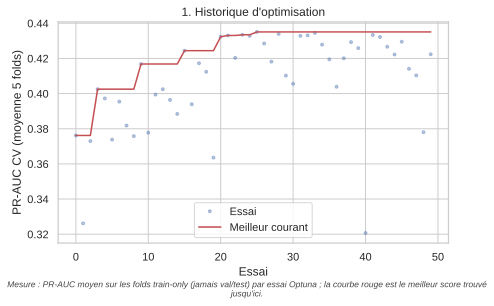

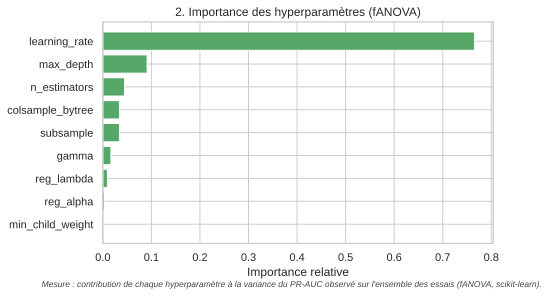

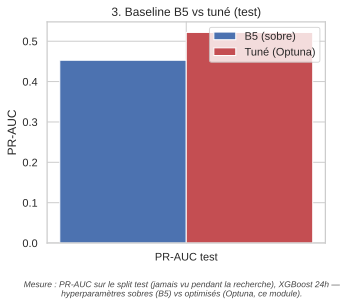

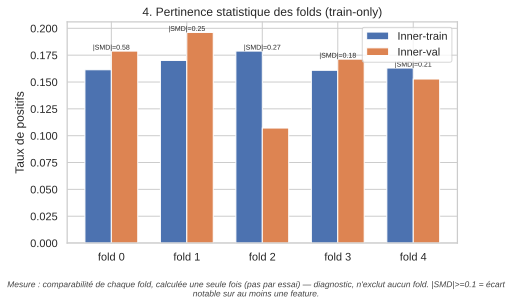

In [5]:
from IPython.display import SVG, display

for fig in sorted((Path(meta["chemin"]) / "figures").glob("*.svg")):
    display(SVG(filename=str(fig)))

## 6. Suivi MLflow & Optuna

- **MLflow** (`uv run mlflow ui --backend-store-uri sqlite:///artifacts/ml/mlflow.db`) : un
  run parent `study_xgboost_24h_<run_id>`, un run imbriqué par essai (params + PR-AUC CV,
  sans artefact modèle), et un run final `xgboost_tuned_24h_<run_id>` (avec le modèle).
- **Optuna** (`artifacts/tuning/optuna.db`) : historique complet des essais, interrogeable via
  `optuna.load_study(study_name=..., storage=...).trials_dataframe()`.

Les deux backends sont gitignorés (locaux, non versionnés).

➡️ **Conclusions**

- **Gain réel et honnête** : PR-AUC test (jamais vu par la recherche) 0,4528 (B5 sobre) ->
  **0,5218** (tuné), soit **+0,069 (+15 % relatif)**. Le tuning valait le coût des 50 essais
  (28 min).
- **Deux hyperparamètres dominent** (importance fANOVA) : `learning_rate` (67 %) et
  `max_depth` (14 %) — le reste compte peu. Le modèle retenu est **plus conservateur** que le
  B5 sobre : taux d'apprentissage bien plus faible (0,026 vs 0,1), arbres moins profonds
  (3 vs 6) et moins nombreux (200 vs 300) — signe que les valeurs "sobres" de B5
  sur-ajustaient légèrement.
- **Pertinence des folds : diagnostic, pas d'alerte** — les écarts observés (température au
  fold le plus ancien, cumul de production, âge des machines) sont les mêmes effets
  mécaniques/saisonniers déjà identifiés au niveau du gold (`03_gold.ipynb` §4) ; rien de
  nouveau qui remettrait en cause la recherche.
- **Hors périmètre de ce module** : le seuil de décision (exploré séparément dans
  `04_maintenance_ml.ipynb` §6) et une éventuelle calibration des probabilités restent des
  leviers complémentaires, non traités ici.